# Experimento 2 — WordCount Distribuido: Spark + HDFS vs. Python Local
**Procesamiento de Alto Volúmen de Datos — PUJ**

## Objetivo
Implementar el clásico **WordCount** sobre un corpus de texto grande almacenado en HDFS, comparando el tiempo de ejecución entre:
1. Python puro (procesamiento local, un solo proceso)
2. Spark con RDD leyendo desde HDFS (procesamiento distribuido)
3. Spark con DataFrame/SQL leyendo desde HDFS

## Relevancia para el taller
Demuestra la ventaja del procesamiento por lotes distribuido de HDFS + Spark sobre el procesamiento secuencial, alineado con la característica de HDFS de acceso secuencial optimizado para alto rendimiento.

In [1]:
import os, time, subprocess, re, collections
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

MASTER_IP    = '10.43.97.145'        # <- Cambia por tu IP
SPARK_MASTER = f'spark://{MASTER_IP}:7077'
HDFS_URI     = f'hdfs://{MASTER_IP}:9000'
CONDA_ENV    = '/opt/conda_envs/pyspark_env'
HADOOP_HOME  = '/nfs/condor/apps/hadoop-3.5.0'
HADOOP_BIN   = f'{HADOOP_HOME}/bin/hdfs'
NFS_DIR      = '/nfs/condor/exp2_local'

os.makedirs('/tmp/exp2', exist_ok=True)
os.makedirs(NFS_DIR, exist_ok=True)

# Forzar Python correcto en workers ANTES de crear la sesion
os.environ['PYSPARK_PYTHON']        = f'{CONDA_ENV}/bin/python'
os.environ['PYSPARK_DRIVER_PYTHON'] = f'{CONDA_ENV}/bin/python'

spark = (
    SparkSession.builder
    .appName('EXP2_WordCount')
    .master(SPARK_MASTER)
    .config('spark.driver.host', MASTER_IP)        # evita hostname del laptop
    .config('spark.driver.bindAddress', MASTER_IP) # idem
    .config('spark.executor.memory', '2g')
    .config('spark.driver.memory', '2g')
    .config('spark.hadoop.fs.defaultFS', HDFS_URI)
    .getOrCreate()
)
sc = spark.sparkContext
print('SparkSession lista')
print(f'  Master : {sc.master}')


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


SparkSession lista
  Master : spark://10.43.97.145:7077


## 2.1 Generar corpus de texto sintético

In [2]:
import random, string, shutil

PALABRAS = [
    'hadoop','spark','hdfs','cluster','nodo','dato','archivo','bloque',
    'replica','namenode','datanode','proceso','memoria','disco','red',
    'paralelo','distribuido','fichero','sistema','almacenamiento',
    'procesamiento','rendimiento','latencia','throughput','replicacion',
    'tolerancia','fallo','configuracion','entorno','python','pyspark',
    'dataframe','rdd','transformacion','accion','particion','shuffle',
    'executor','driver','master','worker','yarn','standalone','local',
] * 20

rng = random.Random(0)

def generar_texto(ruta: str, num_lineas: int):
    with open(ruta, 'w') as f:
        for _ in range(num_lineas):
            n_palabras = rng.randint(8, 20)
            linea = ' '.join(rng.choices(PALABRAS, k=n_palabras))
            f.write(linea + '\n')
    mb = os.path.getsize(ruta) / (1024**2)
    print(f'  {ruta}  ->  {num_lineas:,} lineas  |  {mb:.1f} MB')
    return mb

print('Generando corpus de texto...')
CORPUS_LOCAL = '/tmp/exp2/corpus_grande.txt'
CORPUS_NFS   = f'{NFS_DIR}/corpus_grande.txt'
size_mb = generar_texto(CORPUS_LOCAL, num_lineas=500_000)

# Copiar al NFS para que todos los workers lo vean (lectura local distribuida)
shutil.copy(CORPUS_LOCAL, CORPUS_NFS)
print(f'  Copiado a NFS: {CORPUS_NFS}')

# Subir a HDFS
subprocess.run([HADOOP_BIN, 'dfs', '-mkdir', '-p',
                '/experimentos/exp2_wordcount'], check=True)
subprocess.run([HADOOP_BIN, 'dfs', '-put', '-f',
                CORPUS_LOCAL, '/experimentos/exp2_wordcount/'], check=True)
CORPUS_HDFS = f'{HDFS_URI}/experimentos/exp2_wordcount/corpus_grande.txt'
print(f'  Subido a HDFS: {CORPUS_HDFS}')


Generando corpus de texto...
  /tmp/exp2/corpus_grande.txt  ->  500,000 lineas  |  56.6 MB
  Copiado a NFS: /nfs/condor/exp2_local/corpus_grande.txt


2026-05-21 20:35:38,879 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:38,909 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:39,466 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:39,486 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:39,679 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:39,700 INFO Configuration.deprecation: dfs.permissions in hdfs-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20:35:41,208 INFO Configuration.deprecation: dfs.permissions in core-site.xml is deprecated. Instead, use dfs.permissions.enabled
2026-05-21 20

  Subido a HDFS: hdfs://10.43.97.145:9000/experimentos/exp2_wordcount/corpus_grande.txt


## 2.2 WordCount con Python puro (baseline secuencial)

In [3]:
print('Ejecutando WordCount Python puro...')
t0 = time.perf_counter()

conteo_python = collections.Counter()
with open(CORPUS_LOCAL, 'r') as f:
    for linea in f:
        for palabra in linea.strip().split():
            conteo_python[palabra.lower()] += 1

tiempo_python = time.perf_counter() - t0
top10_python  = conteo_python.most_common(10)

print(f'  Tiempo Python puro : {tiempo_python:.3f} s')
print(f'  Palabras distintas : {len(conteo_python):,}')
print(f'  Top 3              : {top10_python[:3]}')


Ejecutando WordCount Python puro...
  Tiempo Python puro : 3.316 s
  Palabras distintas : 44
  Top 3              : [('hadoop', 159830), ('spark', 159779), ('standalone', 159763)]


## 2.3 WordCount con Spark RDD desde HDFS

In [4]:
print('Ejecutando WordCount Spark RDD desde HDFS...')
t0 = time.perf_counter()

rdd_wc = (
    sc.textFile(CORPUS_HDFS)
      .flatMap(lambda linea: linea.lower().split())
      .filter(lambda w: len(w) > 1)
      .map(lambda w: (w, 1))
      .reduceByKey(lambda a, b: a + b)
      .sortBy(lambda kv: -kv[1])
)

top10_rdd = rdd_wc.take(10)
total_rdd = rdd_wc.count()

tiempo_rdd = time.perf_counter() - t0
print(f'  Tiempo Spark RDD   : {tiempo_rdd:.3f} s')
print(f'  Palabras distintas : {total_rdd:,}')
print(f'  Top 3              : {top10_rdd[:3]}')


Ejecutando WordCount Spark RDD desde HDFS...


  Tiempo Spark RDD   : 9.432 s
  Palabras distintas : 44
  Top 3              : [('hadoop', 159830), ('spark', 159779), ('standalone', 159763)]


## 2.4 WordCount con Spark DataFrame + SQL desde HDFS

In [5]:
print('Ejecutando WordCount Spark DataFrame desde HDFS...')
t0 = time.perf_counter()

df_wc = (
    spark.read.text(CORPUS_HDFS)
         .select(F.explode(F.split(F.lower(F.col('value')), r'\s+')).alias('palabra'))
         .filter(F.length('palabra') > 1)
         .groupBy('palabra')
         .count()
         .orderBy(F.desc('count'))
)

top10_df  = df_wc.limit(10).collect()
total_df  = df_wc.count()

tiempo_df = time.perf_counter() - t0
print(f'  Tiempo Spark DF    : {tiempo_df:.3f} s')
print(f'  Palabras distintas : {total_df:,}')
print(f'  Top 3              : {[(r.palabra, r["count"]) for r in top10_df[:3]]}')


Ejecutando WordCount Spark DataFrame desde HDFS...


[Stage 13:================================================>       (13 + 2) / 15]

  Tiempo Spark DF    : 10.520 s
  Palabras distintas : 44
  Top 3              : [('hadoop', 159830), ('spark', 159779), ('standalone', 159763)]


## 2.5 WordCount con Spark SQL (registrar vista temporal)

In [6]:
print('Ejecutando WordCount Spark SQL...')
t0 = time.perf_counter()

df_texto = spark.read.text(CORPUS_HDFS)
df_texto.createOrReplaceTempView('corpus')

resultado_sql = spark.sql("""
    SELECT palabra, COUNT(*) AS frecuencia
    FROM (
        SELECT EXPLODE(SPLIT(LOWER(value), '\\\\s+')) AS palabra
        FROM corpus
    ) palabras
    WHERE LENGTH(palabra) > 1
    GROUP BY palabra
    ORDER BY frecuencia DESC
    LIMIT 20
""")

top20_sql  = resultado_sql.collect()
tiempo_sql = time.perf_counter() - t0

print(f'  Tiempo Spark SQL   : {tiempo_sql:.3f} s')
print('\n  Top 20 palabras:')
resultado_sql.show(20)


Ejecutando WordCount Spark SQL...


  Tiempo Spark SQL   : 1.565 s

  Top 20 palabras:


+--------------+----------+
|       palabra|frecuencia|
+--------------+----------+
|        hadoop|    159830|
|         spark|    159779|
|    standalone|    159763|
|transformacion|    159697|
|       fichero|    159695|
|   distribuido|    159522|
|          dato|    159470|
|       sistema|    159444|
|        python|    159433|
|       proceso|    159395|
|   rendimiento|    159321|
|          nodo|    159285|
|       archivo|    159259|
|          yarn|    159252|
|        bloque|    159239|
|     dataframe|    159185|
|      datanode|    159180|
|           red|    159172|
|       memoria|    159153|
|       pyspark|    159128|
+--------------+----------+



## 2.6 Comparación y visualización

TABLA DE RESULTADOS - Experimento 2
                Metodo  Tiempo (s) Fuente  Speedup vs Python
   Python puro (local)       3.316  Local               1.00
      Spark RDD (HDFS)       9.432   HDFS               0.35
Spark DataFrame (HDFS)      10.520   HDFS               0.32
      Spark SQL (HDFS)       1.565   HDFS               2.12
Guardado en /tmp/exp2_resultados.csv


/tmp/ipykernel_1327947/2913984202.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(resumen['Metodo'], rotation=15, ha='right')
/tmp/ipykernel_1327947/2913984202.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(resumen['Metodo'], rotation=15, ha='right')


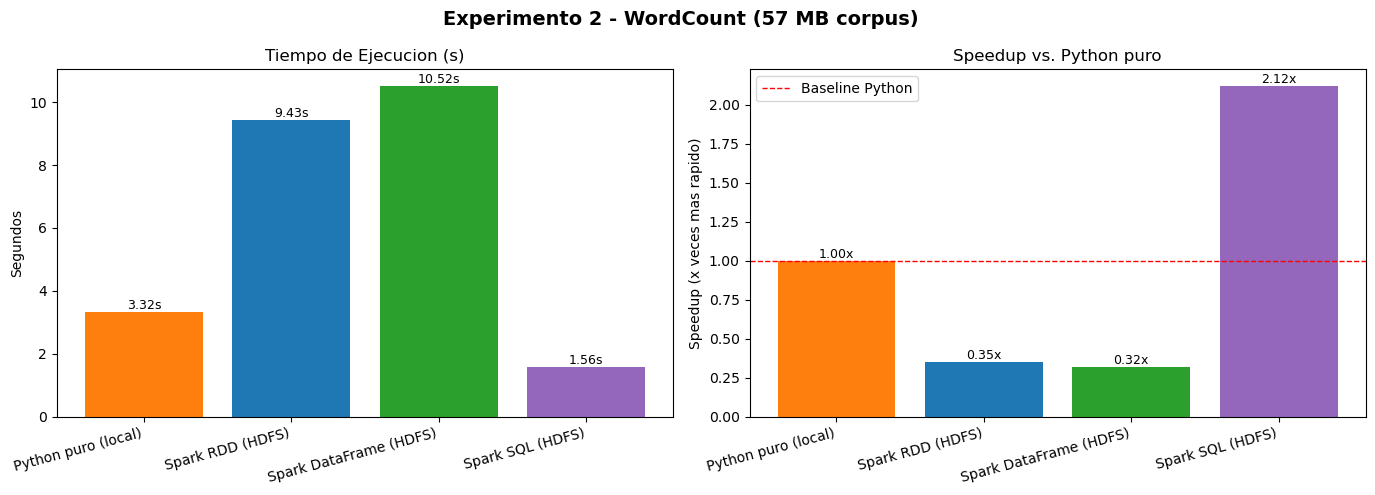

Grafica guardada: /tmp/exp2_grafica.png


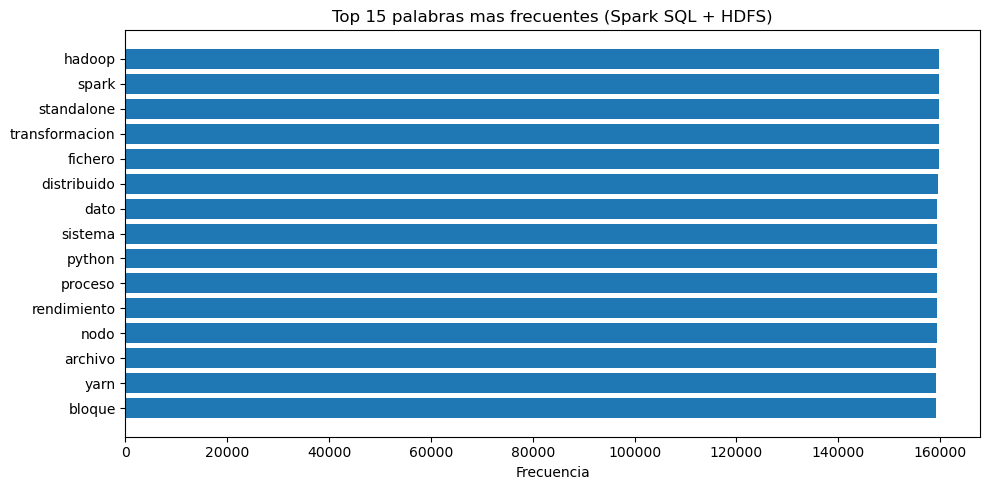

In [7]:
# Tabla resumen
resumen = pd.DataFrame([
    {'Metodo': 'Python puro (local)',    'Tiempo (s)': round(tiempo_python, 3), 'Fuente': 'Local'},
    {'Metodo': 'Spark RDD (HDFS)',       'Tiempo (s)': round(tiempo_rdd,    3), 'Fuente': 'HDFS'},
    {'Metodo': 'Spark DataFrame (HDFS)', 'Tiempo (s)': round(tiempo_df,     3), 'Fuente': 'HDFS'},
    {'Metodo': 'Spark SQL (HDFS)',       'Tiempo (s)': round(tiempo_sql,    3), 'Fuente': 'HDFS'},
])
resumen['Speedup vs Python'] = (resumen['Tiempo (s)'].iloc[0] / resumen['Tiempo (s)']).round(2)

print('TABLA DE RESULTADOS - Experimento 2')
print(resumen.to_string(index=False))
resumen.to_csv('/tmp/exp2_resultados.csv', index=False)
print('Guardado en /tmp/exp2_resultados.csv')

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Experimento 2 - WordCount ({size_mb:.0f} MB corpus)', fontsize=14, fontweight='bold')

colores = ['#FF7F0E', '#1F77B4', '#2CA02C', '#9467BD']

axes[0].bar(resumen['Metodo'], resumen['Tiempo (s)'], color=colores)
axes[0].set_title('Tiempo de Ejecucion (s)')
axes[0].set_ylabel('Segundos')
axes[0].set_xticklabels(resumen['Metodo'], rotation=15, ha='right')
for i, v in enumerate(resumen['Tiempo (s)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontsize=9)

axes[1].bar(resumen['Metodo'], resumen['Speedup vs Python'], color=colores)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1, label='Baseline Python')
axes[1].set_title('Speedup vs. Python puro')
axes[1].set_ylabel('Speedup (x veces mas rapido)')
axes[1].set_xticklabels(resumen['Metodo'], rotation=15, ha='right')
axes[1].legend()
for i, v in enumerate(resumen['Speedup vs Python']):
    axes[1].text(i, v + 0.02, f'{v:.2f}x', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/exp2_grafica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: /tmp/exp2_grafica.png')

# Top 15 palabras
fig2, ax = plt.subplots(figsize=(10, 5))
palabras_top = [r.palabra for r in top20_sql[:15]]
frecuencias  = [r.frecuencia for r in top20_sql[:15]]
ax.barh(palabras_top[::-1], frecuencias[::-1], color='#1F77B4')
ax.set_title('Top 15 palabras mas frecuentes (Spark SQL + HDFS)')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig('/tmp/exp2_top_palabras.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.7 Guardar resultado en HDFS (Parquet)

In [8]:
# Persistir el wordcount completo en HDFS en formato Parquet
OUTPUT_HDFS = f'{HDFS_URI}/experimentos/resultados/wordcount_completo.parquet'

df_wc.write.mode('overwrite').parquet(OUTPUT_HDFS)
print(f'WordCount completo guardado en HDFS como Parquet: {OUTPUT_HDFS}')

# Verificar tamano en HDFS
result = subprocess.run(
    [HADOOP_BIN, 'dfs', '-du', '-h', '/experimentos/resultados/'],
    capture_output=True, text=True
)
print(result.stdout)


WordCount completo guardado en HDFS como Parquet: hdfs://10.43.97.145:9000/experimentos/resultados/wordcount_completo.parquet
1.3 K  2.6 K  /experimentos/resultados/wordcount_completo.parquet



In [9]:
spark.stop()
print('SparkSession detenida.')

SparkSession detenida.
